In [1]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
#import the files
data_train = pd.read_excel('train__1_.xlsx')
data_test = pd.read_excel("test__1_.xlsx")

### **1. EXPLORATORY DATA ANALYSIS**


In this first part, we are going to work directly on the raw data and try to do some features engineering.

In [3]:
#visualize the data
print(data_train.head())
print(data_test.head())

   MatchId  LeagueId       Date  HomeTeamId  AwayTeamId  Home_Goals  \
0     2826       793 2005-04-02         410         908         2.0   
1     2827       793 2005-04-02         338         597         3.0   
2     2828       793 2005-04-02        1364         246         2.0   
3     2829       793 2005-04-02        1088        1397         1.0   
4     2830       793 2005-04-02         830        1412         2.0   

   Away_Goals  Home_Corners  Away_Corners  
0         0.0            15             1  
1         2.0             3             6  
2         3.0            13             2  
3         0.0             2             5  
4         3.0             3             6  
   MatchId  LeagueId       Date  HomeTeamId  AwayTeamId  Line   Over  Under  \
0        1       741 2011-04-01         342         694   9.5  1.790   1.80   
1        2       741 2011-04-01        1424         270  11.5  1.920   2.00   
2        3       729 2011-04-01         691        1137  10.5  1.970   1

In [4]:
#creation of new features 
data_train["Total_goals"] = data_train["Away_Goals"]+data_train["Home_Goals"]
data_train["Total_corners"]=data_train["Away_Corners"]+data_train["Home_Corners"]

The variance-to-mean ratio (VMR) represents the variance divided by the mean, where a value above 1 indicates overdispersion. To use the poisson distribution, we need to have th emean equal to the variance approximately. 

In [5]:
#we are gonna check the variance and mean per league 
mean_per_league = data_train.groupby("LeagueId")["Total_corners"].mean()
var_per_league = data_train.groupby("LeagueId")["Total_corners"].var()
VMR_per_league = var_per_league / mean_per_league
VMR_TOT= data_train['Total_corners'].var()/data_train['Total_corners'].mean()

league_stats = pd.DataFrame({
    "Mean" : mean_per_league,
    "Variance" : var_per_league,
    "VMR" : VMR_per_league
})
print("Statistics of the mean, var and VMR of the corners per League")
print(league_stats.round(2))
print(f"The VMR for the entire dataset is {VMR_TOT:.2f}")

Statistics of the mean, var and VMR of the corners per League
           Mean  Variance   VMR
LeagueId                       
729       10.89     13.20  1.21
734        9.43     10.28  1.09
741       10.62     12.05  1.13
764       10.58     12.91  1.22
776        9.74     10.28  1.05
781       10.51     13.05  1.24
793       10.97     12.26  1.12
795        9.69     10.66  1.10
800       10.10     11.33  1.12
801       10.25     11.71  1.14
811        9.49     11.31  1.19
813        9.64     10.86  1.13
816       10.73     12.01  1.12
The VMR for the entire dataset is 1.17


In this part of code, we create 8 other features form the one that we have :

For the Home Team (and same for away team)
 - HomeTeam_AvgHomeGoals : Average goals scored by the home team when playing at home
 - HomeTeam_AvgAwayGoals : Average goals scored by the home team when playing away
 - HomeTeam_AvgHomeCorners :Average corners earned by the home team when playing at home.
 - HomeTeam_AvgAwayCorners:Average corners earned by the home team when playing away.


In [6]:
#date in the right format
data_train['Date'] = pd.to_datetime(data_train['Date'])

#calculate team averages(home and away)
#home performance (when the team was HomeTeamId)
home_stats = data_train.groupby('HomeTeamId').agg({
    'Home_Goals': 'mean',    
    'Home_Corners': 'mean'    
}).rename(columns={
    'Home_Goals': 'Team_AvgHomeGoals',
    'Home_Corners': 'Team_AvgHomeCorners'
}).reset_index()

#away performances (when the team was AwayTeamId)
away_stats = data_train.groupby('AwayTeamId').agg({
    'Away_Goals': 'mean',      
    'Away_Corners': 'mean'   
}).rename(columns={
    'Away_Goals': 'Team_AvgAwayGoals',
    'Away_Corners': 'Team_AvgAwayCorners'
}).reset_index()

#merging for the team
team_stats = pd.merge(
    home_stats, 
    away_stats, 
    left_on='HomeTeamId', 
    right_on='AwayTeamId',
    how='outer'
).rename(columns={'HomeTeamId': 'TeamId'}).drop('AwayTeamId', axis=1)


#merge
# HOME TEAM
data_train = pd.merge(
    data_train,
    team_stats,
    left_on='HomeTeamId',
    right_on='TeamId',
    how='left'
).rename(columns={
    'Team_AvgHomeGoals': 'HomeTeam_AvgHomeGoals',
    'Team_AvgAwayGoals': 'HomeTeam_AvgAwayGoals',
    'Team_AvgHomeCorners': 'HomeTeam_AvgHomeCorners',
    'Team_AvgAwayCorners': 'HomeTeam_AvgAwayCorners'
}).drop('TeamId', axis=1)

#AWAY TEAM
data_train = pd.merge(
    data_train,
    team_stats,
    left_on='AwayTeamId',
    right_on='TeamId',
    how='left'
).rename(columns={
    'Team_AvgHomeGoals': 'AwayTeam_AvgHomeGoals',
    'Team_AvgAwayGoals': 'AwayTeam_AvgAwayGoals',
    'Team_AvgHomeCorners': 'AwayTeam_AvgHomeCorners',
    'Team_AvgAwayCorners': 'AwayTeam_AvgAwayCorners'
}).drop('TeamId', axis=1)



In this part we create 2 other variables to add to our model :
- HomeTeam_Last5HomeCorners
- AwayTeam_Last5AwayCorners

It is a rolling average of the last 5 corners that the home team earned during the last 5 matches. For the first macthes where we don't have any historical data - we fill the league average.

In [7]:
#sort the data with the date and the team ID
data_train = data_train.sort_values(['HomeTeamId', 'Date'])

#home Team's rolling average for home corners on 5 games
data_train['HomeTeam_Last5HomeCorners'] = (
    data_train.groupby('HomeTeamId')['Home_Corners']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
)

#forward-fill missing values
data_train['HomeTeam_Last5HomeCorners'] = (
    data_train.groupby('HomeTeamId')['HomeTeam_Last5HomeCorners']
    .ffill()
)
#SAME AWAY
data_train = data_train.sort_values(['AwayTeamId', 'Date'])

data_train['AwayTeam_Last5AwayCorners'] = (
    data_train.groupby('AwayTeamId')['Away_Corners']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
)

data_train['AwayTeam_Last5AwayCorners'] = (
    data_train.groupby('AwayTeamId')['AwayTeam_Last5AwayCorners']
    .ffill()
)

#fill NAN with league averages (for teams with <5 games)
league_avg_home = data_train.groupby('LeagueId')['Home_Corners'].mean()
league_avg_away = data_train.groupby('LeagueId')['Away_Corners'].mean()

data_train['HomeTeam_Last5HomeCorners'] = data_train['HomeTeam_Last5HomeCorners'].fillna(
    data_train['LeagueId'].map(league_avg_home)
)
data_train['AwayTeam_Last5AwayCorners'] = data_train['AwayTeam_Last5AwayCorners'].fillna(
    data_train['LeagueId'].map(league_avg_away)
)

data_train = data_train.sort_index()

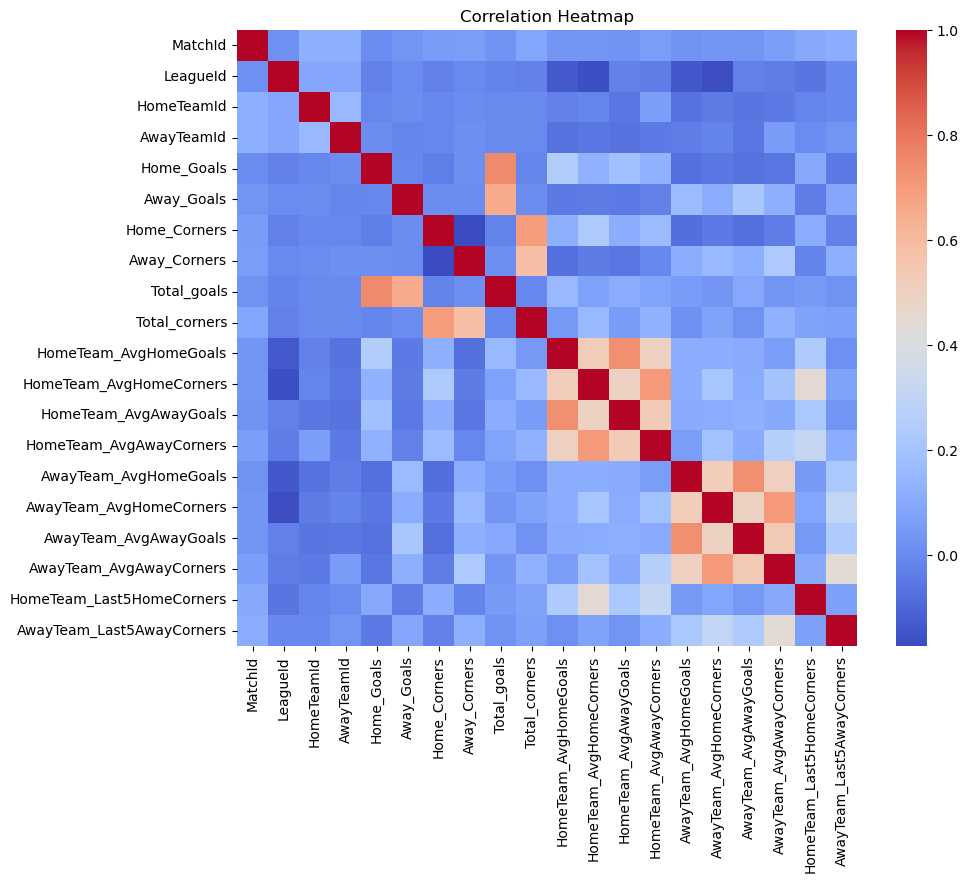

In [8]:

#correlation matrix to see how correlated the differnet features are 
numerical_cols = data_train.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
data_train.isna().sum()

MatchId                      0
LeagueId                     0
Date                         0
HomeTeamId                   0
AwayTeamId                   0
Home_Goals                   8
Away_Goals                   8
Home_Corners                 0
Away_Corners                 0
Total_goals                  8
Total_corners                0
HomeTeam_AvgHomeGoals        0
HomeTeam_AvgHomeCorners      0
HomeTeam_AvgAwayGoals        0
HomeTeam_AvgAwayCorners      0
AwayTeam_AvgHomeGoals        9
AwayTeam_AvgHomeCorners      9
AwayTeam_AvgAwayGoals        9
AwayTeam_AvgAwayCorners      9
HomeTeam_Last5HomeCorners    0
AwayTeam_Last5AwayCorners    0
dtype: int64

Since Team ID 776 appears only as an away team (AwayTeamId) and has no historical data in the dataset (all its AwayTeam_Avg* stats are NaN) - we replaced it by the league average nb of corners and goals.

In [10]:
#average nb of corners 
league_avg_away_goals = data_train.groupby('LeagueId')['Away_Goals'].mean()
league_avg_away_corners = data_train.groupby('LeagueId')['Away_Corners'].mean()

#fileter and replace
mask = data_train['AwayTeamId'] == 776 

data_train.loc[mask, 'AwayTeam_AvgHomeGoals'] = data_train.loc[mask, 'LeagueId'].map(league_avg_away_goals)
data_train.loc[mask, 'AwayTeam_AvgHomeCorners'] = data_train.loc[mask, 'LeagueId'].map(league_avg_away_corners)
data_train.loc[mask, 'AwayTeam_AvgAwayGoals'] = data_train.loc[mask, 'LeagueId'].map(league_avg_away_goals)
data_train.loc[mask, 'AwayTeam_AvgAwayCorners'] = data_train.loc[mask, 'LeagueId'].map(league_avg_away_corners)

In [11]:
#we had 8 misisng values that we replace with 0
data_train[['Home_Goals', 'Away_Goals', 'Total_goals']] = data_train[['Home_Goals', 'Away_Goals', 'Total_goals']].fillna(0)

In [ ]:
#adjustement
print(f"Number of missing values : {data_train.isna().sum().sum()}")
pd.set_option('display.float_format', '{:.2f}'.format) # take only 2 decimals 

#create ou validation set : we use the year 2010 as our validation set ad the year 2005 to 2009 as our training set
data_train['Year'] = data_train['Date'].dt.year
last_year = data_train['Year'].max()
training_data = data_train[data_train['Year']<last_year].copy()
val_data = data_train[data_train['Year']==last_year].copy()

#remove the column year
training_data.drop('Year', axis = 1, inplace=True)
val_data.drop('Year', axis =1 , inplace = True)


Number of missing values : 0


### **2. 1ST SET OF MODELISATION  : POISSON / NEGATIVE BINOMIALE /XG BOOST**

In [13]:
!pip install xgboost

In [14]:
#LIBRARIES
import statsmodels.api as sm
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

With this result of overdispersion, we should not use the poisson distribution because it assumes that the mean is equal to the variance.

In [15]:

#features
all_features = [
    'LeagueId', 'Home_Goals', 'Away_Goals',
    'HomeTeam_AvgHomeGoals', 'HomeTeam_AvgHomeCorners',
    'HomeTeam_AvgAwayGoals', 'HomeTeam_AvgAwayCorners',
    'AwayTeam_AvgHomeGoals', 'AwayTeam_AvgHomeCorners',
    'AwayTeam_AvgAwayGoals', 'AwayTeam_AvgAwayCorners',
    'HomeTeam_Last5HomeCorners', 'AwayTeam_Last5AwayCorners'
]

X = training_data[all_features]
y = training_data['Total_corners']

#intercept
X = sm.add_constant(X)

## **Poisson**

**Accuracy : 11.5%**

In [17]:
poisson_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_results.summary())  #check for overdispersion (Pearson chi²/df >> 1)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                18984
Model:                            GLM   Df Residuals:                    18970
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -49705.
Date:                Wed, 06 Aug 2025   Deviance:                       21343.
Time:                        14:26:56   Pearson chi2:                 2.10e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05016
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [18]:
#tryy our model on the valdation set
X_val_P = sm.add_constant(val_data[all_features]) 

#get the predicted corners
val_data['Predicted_Corners_P'] = poisson_results.predict(X_val_P)
val_data['Predicted_Rounded_P'] = val_data['Predicted_Corners_P'].round().astype(int)


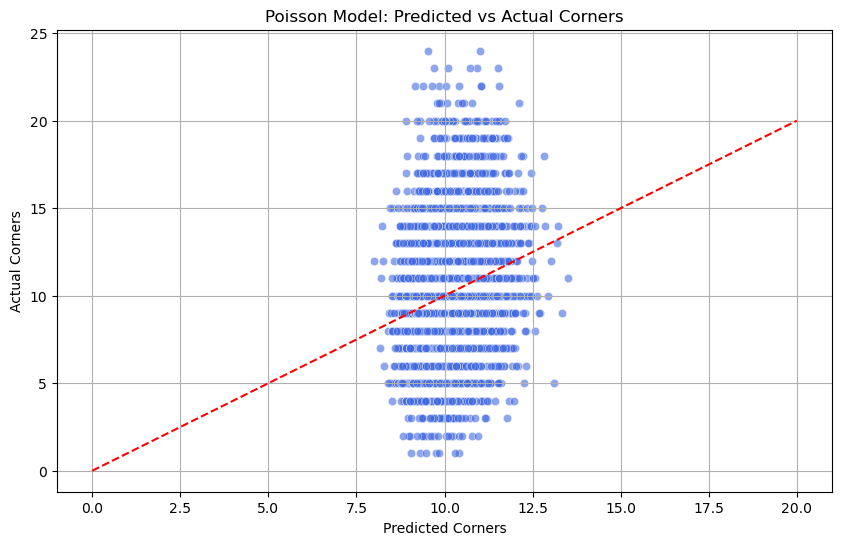

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Predicted_Corners_P',
    y='Total_corners',
    data=val_data,
    alpha=0.6,
    color='royalblue'
)
plt.plot([0, 20], [0, 20], 'r--')
plt.xlabel('Predicted Corners')
plt.ylabel('Actual Corners')
plt.title('Poisson Model: Predicted vs Actual Corners')
plt.grid(True)
plt.show()

In [20]:
## fct to calculate the exact nb of corners correct with the percentile
def percent_within(error_series, tolerance):
    return (abs(error_series) <= tolerance).mean()

In [21]:

#metrics
val_data['Error_P'] = val_data['Total_corners'] - val_data['Predicted_Rounded_P']
mae = mean_absolute_error(val_data['Total_corners'], val_data['Predicted_Rounded_P'])
r2 = r2_score(val_data['Total_corners'], val_data['Predicted_Corners_P'])

print(f"MAE: {mae:.2f} corners")
print(f"R²: {r2:.2f}")
print(f"Exact match: {percent_within(val_data['Error_P'], 0):.1%}")
print(f"Within ±1: {percent_within(val_data['Error_P'], 1):.1%}")
print(f"Within ±2: {percent_within(val_data['Error_P'], 2):.1%}")
print(f"Within ±3: {percent_within(val_data['Error_P'], 3):.1%}")

MAE: 2.72 corners
R²: 0.03
Exact match: 11.5%
Within ±1: 34.0%
Within ±2: 54.3%
Within ±3: 70.3%


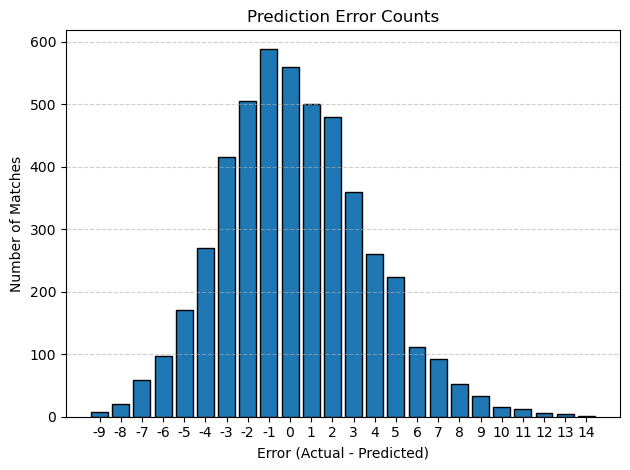

In [22]:
error_counts = val_data['Error_P'].value_counts().sort_index()

plt.bar(error_counts.index.astype(str), error_counts.values, edgecolor='black')
plt.title("Prediction Error Counts")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Number of Matches")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### **NEGATIVE BINOMIAL**

**Accuracy : 11.5%**

In [23]:
#set alpha 
variance = y.var()
mean = y.mean()
alpha_manual = (variance - mean) / (mean ** 2)
print(f"The alpha from the training data is : {alpha_manual:.3f}")

The alpha from the training data is : 0.016


In [24]:
nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=0.016)).fit()
print(nb_model.summary())  # Check if alpha (dispersion) is significant


                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                18984
Model:                            GLM   Df Residuals:                    18970
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -49663.
Date:                Wed, 06 Aug 2025   Deviance:                       18412.
Time:                        14:27:35   Pearson chi2:                 1.81e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.04329
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [25]:
#get the predicted corners

X_val_nb = sm.add_constant(val_data[all_features]) 
val_data['Predicted_Corners_NB'] = nb_model.predict(X_val_nb)
val_data['Predicted_Rounded_NB'] = val_data['Predicted_Corners_NB'].round().astype(int)

In [26]:
val_data['Error_NB'] = val_data['Total_corners'] - val_data['Predicted_Rounded_NB']
mae = mean_absolute_error(val_data['Total_corners'], val_data['Predicted_Rounded_NB'])
r2 = r2_score(val_data['Total_corners'], val_data['Predicted_Corners_NB'])


print(f"MAE: {mae:.2f} corners.")
print(f"R2:{r2:.2f}.")
print(f"Exact match: {percent_within(val_data['Error_NB'], 0):.1%}")
print(f"Within ±1: {percent_within(val_data['Error_NB'], 1):.1%}")
print(f"Within ±2: {percent_within(val_data['Error_NB'], 2):.1%}")
print(f"Within ±3: {percent_within(val_data['Error_NB'], 3):.1%}")


MAE: 2.72 corners.
R2:0.03.
Exact match: 11.5%
Within ±1: 34.0%
Within ±2: 54.4%
Within ±3: 70.3%


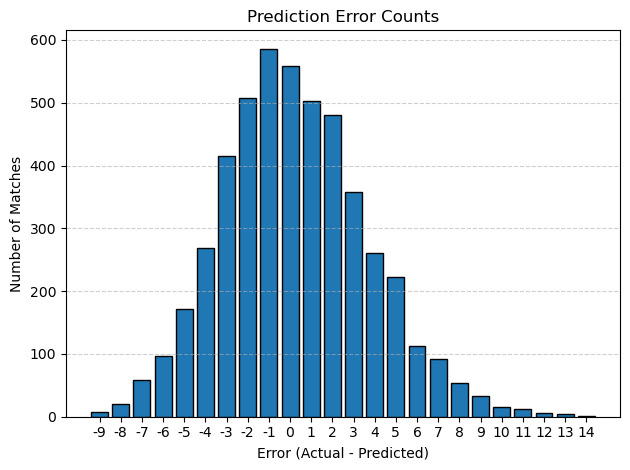

In [27]:
error_counts_NB = val_data['Error_NB'].value_counts().sort_index()

plt.bar(error_counts_NB.index.astype(str), error_counts_NB.values, edgecolor='black')
plt.title("Prediction Error Counts")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Number of Matches")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **XGBOOST**

**Accuracy : 11.7%**


In [28]:
model = xgb.XGBRegressor(
    objective='count:poisson', 
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric= 'mae'

)

model.fit(X, y)

#PREDICT
X_val_xg = sm.add_constant(val_data[all_features]) 
val_data['Predicted_XG'] = model.predict(X_val_xg)
val_data['Round_predicted_XG']= val_data['Predicted_XG'].round().astype(int)


val_data['Error_XG'] = val_data['Total_corners'] - val_data['Round_predicted_XG']
mae = mean_absolute_error(val_data['Total_corners'], val_data['Round_predicted_XG'])
r2 = r2_score(val_data['Total_corners'], val_data['Predicted_XG'])


print(f"MAE: {mae:.2f} corners.")
print(f"R2:{r2:.2f}.")
print(f"Exact match: {percent_within(val_data['Error_XG'], 0):.1%}")
print(f"Within ±1: {percent_within(val_data['Error_XG'], 1):.1%}")
print(f"Within ±2: {percent_within(val_data['Error_XG'], 2):.1%}")
print(f"Within ±3: {percent_within(val_data['Error_XG'], 3):.1%}")

MAE: 2.72 corners.
R2:0.03.
Exact match: 11.7%
Within ±1: 34.0%
Within ±2: 54.5%
Within ±3: 70.0%


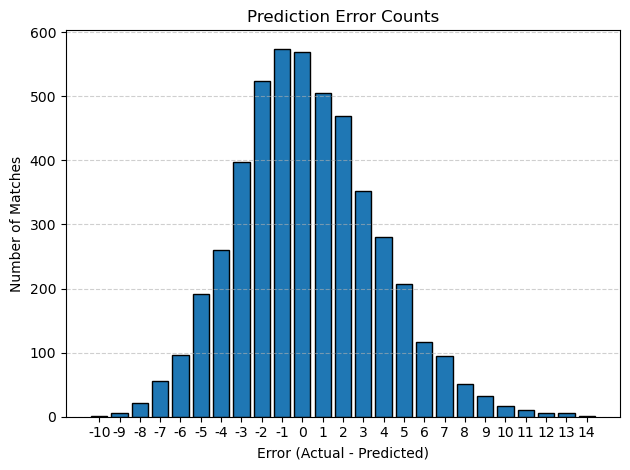

In [29]:
error_counts_XG = val_data['Error_XG'].value_counts().sort_index()

plt.bar(error_counts_XG.index.astype(str), error_counts_XG.values, edgecolor='black')
plt.title("Prediction Error Counts")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Number of Matches")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **3. XG BOOST : CREATION OF A DIFFERENT MODEL FOR THE DIFFERNET LEAGUES**

**Accuracy : 13.2%**

In [30]:
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline

In [31]:
#keagues specific
leagues = data_train['LeagueId'].unique()

In [32]:
league_metrics = {}

for league in leagues:
    #filter the data
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    #if league is equal to 0
    if len(league_val) == 0:
        print(f"Skipping league {league} - no validation data")
        continue
        
    #feature selection
    features = [
        'HomeTeam_AvgHomeCorners',
        'AwayTeam_AvgAwayCorners',
        'HomeTeam_Last5HomeCorners', 
        'AwayTeam_Last5AwayCorners',
        'Total_goals',
        'HomeTeam_AvgHomeGoals', 
        'AwayTeam_AvgHomeGoals', 
        'AwayTeam_AvgHomeCorners',
        'HomeTeam_AvgAwayCorners',
        'AwayTeam_AvgAwayGoals', 

    ]    
    X_train = league_train[features]
    y_train = league_train['Total_corners']
    X_val = league_val[features]
    y_val = league_val['Total_corners']
    
    #train
    model = xgb.XGBRegressor(
        objective='count:poisson',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05
    ).fit(X_train, y_train)
    
    #prediction
    preds = model.predict(X_val)
    preds_rounded = preds.round().astype(int)
    
    #metrics
    assert len(y_val) == len(preds_rounded), "Length mismatch between y_val and predictions"
    
    league_metrics[league] = {
        'MAE': mean_absolute_error(y_val, preds_rounded),
        'R2': r2_score(y_val, preds),
        'Exact_Matches': (y_val == preds_rounded).sum(),
        'Within_One': (abs(y_val - preds_rounded) <= 1).sum(),
        'within_2' : (abs(y_val - preds_rounded) <= 2).sum(),
        'Total_Matches': len(y_val)
    }

#results
print("{:<8} {:<6} {:<6} {:<8} {:<8} {:<8} {:<8}".format(
    'League', 'MAE', 'R2', 'Exact', '±1', '±2','Matches'))
for league, metrics in league_metrics.items():
    print("{:<8} {:<6.2f} {:<6.3f} {:<8} {:<8} {:<8} {:<8}".format(
        league,
        metrics['MAE'],
        metrics['R2'],
        f"{metrics['Exact_Matches']}/{metrics['Total_Matches']}",
        f"{metrics['Within_One']}/{metrics['Total_Matches']}",
        f"{metrics['within_2']}/{metrics['Total_Matches']}",
        metrics['Total_Matches']
    ))

# Aggregate statistics
total_matches = sum(m['Total_Matches'] for m in league_metrics.values())
total_mae = sum(m['MAE']*m['Total_Matches'] for m in league_metrics.values())
total_exact = sum(m['Exact_Matches'] for m in league_metrics.values())
total_within_one = sum(m['Within_One'] for m in league_metrics.values())
total_within_two = sum(m['within_2'] for m in league_metrics.values())


print(f"\nOverall Performance:")
print(f"Weighted MAE {total_mae/total_matches:.3f}")
print(f"Exact Predictions: {total_exact}/{total_matches} ({total_exact/total_matches:.2%})")
print(f"±1 Corner Accuracy: {total_within_one}/{total_matches} ({total_within_one/total_matches:.2%})")
print(f"±2 Corner Accuracy: {total_within_two}/{total_matches} ({total_within_two/total_matches:.2%})")


League   MAE    R2     Exact    ±1       ±2       Matches 
793      2.43   0.198  68/540   216/540  321/540  540     
781      2.23   0.252  31/221   95/221   149/221  221     
795      2.38   0.234  44/306   114/306  186/306  306     
811      2.35   0.169  53/361   142/361  217/361  361     
800      2.53   0.203  54/451   154/451  245/451  451     
741      2.52   0.168  51/378   139/378  222/378  378     
729      2.52   0.207  44/377   126/377  222/377  377     
801      2.50   0.233  47/378   148/378  215/378  378     
776      2.00   0.289  64/302   142/302  202/302  302     
816      2.54   0.122  54/524   197/524  303/524  524     
734      2.38   0.241  36/296   113/296  181/296  296     
764      2.17   0.320  37/255   105/255  172/255  255     
813      2.49   0.185  57/457   166/457  261/457  457     

Overall Performance:
Weighted MAE 2.415
Exact Predictions: 640/4846 (13.21%)
±1 Corner Accuracy: 1857/4846 (38.32%)
±2 Corner Accuracy: 2896/4846 (59.76%)


### **XG BOOST WITH FEATURE SELECTION : LASSO AND FORWARD STEPWISE**
**Accuracy : 12.9%**

In [ ]:
import numpy as np
league_metrics = {}

for league in leagues:
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    if len(league_val) == 0:
        print(f"Skipping league {league} - no validation data")
        continue
        
    #CREATION OF EXTRA FETAURES
    def create_features(df):
        X = df[base_features].copy()
        X['Interaction_Corners'] = X['HomeTeam_AvgHomeCorners'] * X['AwayTeam_AvgAwayCorners']
        X['Interaction_Goals'] = X['Total_goals'] * X['HomeTeam_AvgHomeCorners']
        return X.values  

    base_features = ['HomeTeam_AvgHomeCorners',
        'AwayTeam_AvgAwayCorners',
        'HomeTeam_Last5HomeCorners', 
        'AwayTeam_Last5AwayCorners',
        'Total_goals',
        'HomeTeam_AvgHomeGoals', 
        'AwayTeam_AvgHomeGoals', 
        'AwayTeam_AvgHomeCorners',
        'HomeTeam_AvgAwayCorners',
        'AwayTeam_AvgAwayGoals', 

    ]  
    
    X_train = create_features(league_train)
    y_train = league_train['Total_corners'].values
    X_val = create_features(league_val)
    y_val = league_val['Total_corners'].values

    # --- FEATURE SELECTION PIPELINE --------------------------------------------
    # Option 1: Lasso (L1 penalty)
    lasso = LassoCV(cv=5, max_iter=10000)
    lasso.fit(X_train, y_train)
    
    #get features with non-zero coefficients
    selected_mask = lasso.coef_ != 0
    selected_features = np.array(base_features + ['Interaction_Corners', 'Interaction_Goals'])[selected_mask]
    print(f"League {league}: Selected {len(selected_features)} features: {selected_features}")
    # Option 2: Stepwise Forward Selection (slower but thorough)
   # if len(selected_features) == 0:  #good if lasso remove all the coefficents
      #  sfs = SequentialFeatureSelector(
           # xgb.XGBRegressor(objective='count:poisson', n_estimators=50),
          #  n_features_to_select='auto',
          #  tol=0.01,
         #   direction='forward'
        #)
       # sfs.fit(X_train, y_train)
      #  selected_mask = sfs.support_
     #   selected_features = np.array(base_features + ['Interaction_Corners', 'Interaction_Goals'])[selected_mask]
    #
    #print(f"League {league}: Selected {len(selected_features)} features: {selected_features}")
    #############################################################################################

    #training
    model = xgb.XGBRegressor(
        objective='count:poisson',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=0.1,  #small L1for sparsity
        reg_lambda=0.1  
    ).fit(X_train[:, selected_mask], y_train)
    
    #predict
    preds = model.predict(X_val[:, selected_mask])
    preds_rounded = preds.round().astype(int)
    
    league_metrics[league] = {
        'MAE': mean_absolute_error(y_val, preds_rounded),
        'R2': r2_score(y_val, preds),
        'Exact_Matches': (y_val == preds_rounded).sum(),
        'Within_One': (abs(y_val - preds_rounded) <= 1).sum(),
        'Selected_Features': list(selected_features),
        'Total_Matches' : len(y_val)
    }



League 793: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 781: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 795: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 811: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 800: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 741: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 729: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 801: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 776: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 816: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 734: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 764: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']
League 813: Selected 2 features: ['Interaction_Corners' 'Interaction_Goals']

In [34]:
#PRINT THE RESULTS WITH THE AGGREGATE STAT
total_matches = sum(m['Total_Matches'] for m in league_metrics.values())
total_exact = sum(m['Exact_Matches'] for m in league_metrics.values())
total_within_one = sum(m['Within_One'] for m in league_metrics.values())

#weighted MAE (league-size adjusted)
weighted_mae = sum(
    m['MAE'] * (m['Total_Matches'] / total_matches) 
    for m in league_metrics.values()
)


for league, metrics in league_metrics.items():
    print(f"""
    League {league}:
    - MAE: {metrics['MAE']:.2f}
    - Features: {metrics['Selected_Features']}
    - %±1: {metrics['Within_One']/metrics['Total_Matches']:.1%}
    - Exact matches: {metrics['Exact_Matches']/metrics['Total_Matches']:.1%}
    """)

#overall statistics
print(f"""
\033[1mOVERALL PERFORMANCE ACROSS ALL LEAGUES:\033[0m
- Weighted MAE: {weighted_mae:.2f}
- Exact Prediction Rate: {total_exact}/{total_matches} ({total_exact/total_matches:.1%})
- ±1 Corner Accuracy: {total_within_one}/{total_matches} ({total_within_one/total_matches:.1%})
""")


    League 793:
    - MAE: 2.49
    - Features: ['AwayTeam_Last5AwayCorners', 'AwayTeam_AvgHomeCorners', 'Interaction_Corners', 'Interaction_Goals']
    - %±1: 39.4%
    - Exact matches: 10.9%
    

    League 781:
    - MAE: 2.43
    - Features: ['Interaction_Corners']
    - %±1: 40.3%
    - Exact matches: 14.0%
    

    League 795:
    - MAE: 2.46
    - Features: ['HomeTeam_AvgHomeCorners', 'AwayTeam_AvgHomeGoals', 'AwayTeam_AvgHomeCorners', 'HomeTeam_AvgAwayCorners', 'Interaction_Corners', 'Interaction_Goals']
    - %±1: 34.6%
    - Exact matches: 13.1%
    

    League 811:
    - MAE: 2.38
    - Features: ['HomeTeam_Last5HomeCorners', 'Interaction_Corners', 'Interaction_Goals']
    - %±1: 39.9%
    - Exact matches: 15.2%
    

    League 800:
    - MAE: 2.49
    - Features: ['HomeTeam_AvgHomeCorners', 'HomeTeam_Last5HomeCorners', 'AwayTeam_Last5AwayCorners', 'HomeTeam_AvgAwayCorners', 'Interaction_Corners', 'Interaction_Goals']
    - %±1: 35.0%
    - Exact matches: 13.5%
    

  

### **HYBRIDE XG BOOST: TARGET FCT US THE RESIDUAL OF THE NEGATIVE BINOMIALE**

**Accuracy : 14.9%**

In [59]:
#CREATION OF EXTRA INTERACTIONS BETWEEN THE FEATURES :

def create_interactions(df):
    """Create interaction terms and return DataFrame with all features"""
    interactions = df.copy()
    #corners
    interactions['Home_Away_Corners'] = df['HomeTeam_AvgHomeCorners'] * df['AwayTeam_AvgAwayCorners']
    interactions['Recent_Corners'] = df['HomeTeam_Last5HomeCorners'] * df['AwayTeam_Last5AwayCorners']
    #goals
    interactions['Goals_HomeCorners'] = df['Total_goals'] * df['HomeTeam_AvgHomeCorners']
    interactions['Goals_AwayDefense'] = df['Total_goals'] * (1/df['AwayTeam_AvgAwayCorners'].clip(0.1)) #avoid div /0
    return interactions

In [60]:
#HYBRID NB XG BOOST
def hybrid_nb_xgboost(train_data, val_data, base_features, target='Total_corners'):
    
    #FEATURE ENGINEERING
    X_train = create_interactions(train_data[base_features])
    X_val = create_interactions(val_data[base_features])
    y_train = train_data[target]
    y_val = val_data[target]
    
    #NB GLM 
    X_train_const = add_constant(X_train)
    nb_model = sm.GLM(
        y_train,
        X_train_const,
        family=sm.families.NegativeBinomial(alpha=0.2)
    ).fit()
    
    print(f"\nNB Model Summary for League:")
    print(nb_model.summary())
    
    #XG BOOST
    residuals = y_train - nb_model.predict(X_train_const)
    
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=0.1 
    ).fit(X_train, residuals)
    
    #PRED
    val_preds = np.round(
        np.maximum(
            nb_model.predict(add_constant(X_val)) + 
            xgb_model.predict(X_val),
        0)
    )
    
    #METRICS
    return {
        'MAE': mean_absolute_error(y_val, val_preds),
        'Exact_Matches': (y_val == val_preds).mean(),
        'Within_One': (abs(y_val - val_preds) <= 1).mean(),
        'Total_Matches': len(y_val),
        'Top_Features': pd.Series(xgb_model.feature_importances_, index=X_train.columns)
                          .sort_values(ascending=False)[:5].to_dict()
    }

In [63]:
#implementation
from statsmodels.api import add_constant
base_features = [
    'HomeTeam_AvgHomeCorners',
    'AwayTeam_AvgAwayCorners',
    'HomeTeam_Last5HomeCorners',
    'AwayTeam_Last5AwayCorners',
    'Total_goals'
]

league_metrics = {}
for league in leagues:
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    if len(league_val) == 0:
        print(f"Skipping league {league} - no data")
        continue
        
    metrics = hybrid_nb_xgboost(league_train, league_val, base_features)
    league_metrics[league] = metrics
    
    print(f"\nLeague {league} Top Features:")
    for feat, importance in metrics['Top_Features'].items():
        print(f"- {feat}: {importance:.3f}")

#aggregate results
total_matches = sum(m['Total_Matches'] for m in league_metrics.values())
avg_mae = sum(m['MAE'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_exact = sum(m['Exact_Matches'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_within_one = sum(m['Within_One'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches

print(f"""
\033[1mFINAL RESULTS\033[0m
- Weighted MAE: {avg_mae:.2f}
- Exact Prediction Rate: {avg_exact:.1%}
- ±1 Corner Accuracy: {avg_within_one:.1%}
""")


NB Model Summary for League:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                 2658
Model:                            GLM   Df Residuals:                     2648
Model Family:        NegativeBinomial   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7594.9
Date:                Sun, 03 Aug 2025   Deviance:                       958.65
Time:                        16:37:43   Pearson chi2:                     916.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.004915
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

### **XG BOOST HYBRIF WITH FOCUS NB + CREATION OF NEW INTERACTIONS BETWEEN THE FEATURES AND ENHANCEMENT OF SETTINGS INSIDE XGBOOST**

**Accuracy : 18.4%**

In [64]:
##CREATION OF NEW INTERCATIONS :


def create_interactions(df):
    
    interactions = df.copy()
    #corners
    interactions['Home_Away_Corners'] = df['HomeTeam_AvgHomeCorners'] * df['AwayTeam_AvgAwayCorners']
    interactions['Recent_Corners'] = df['HomeTeam_Last5HomeCorners'] * df['AwayTeam_Last5AwayCorners']
    #goals
    interactions['Goals_HomeCorners'] = df['Total_goals'] * df['HomeTeam_AvgHomeCorners']
    interactions['Goals_AwayDefense'] = df['Total_goals'] * (1/df['AwayTeam_AvgAwayCorners'].clip(0.1))  #avoid div /0

    #new  corners features focus
    interactions['Defensive_Pressure'] = (1/df['AwayTeam_AvgAwayCorners'].clip(0.1)) * df['HomeTeam_Last5HomeCorners']
    interactions['Attack_vs_Defense'] = df['HomeTeam_AvgHomeCorners'] / df['AwayTeam_AvgAwayCorners'].clip(1)
    interactions['Recent_Form_Gap'] = df['HomeTeam_Last5HomeCorners'] - df['AwayTeam_Last5AwayCorners']
    
    #add weight to recent matches 
    interactions['Home_Weighted_Corners'] = df['HomeTeam_Last5HomeCorners'] * 0.5 + df['HomeTeam_AvgHomeCorners'] * 0.5

    #rolling std dev per team
    home_std = df.groupby('HomeTeamId')['HomeTeam_AvgHomeCorners'].transform(lambda x: x.rolling(10, min_periods=5).std().fillna(3.0))
    away_std = df.groupby('AwayTeamId')['AwayTeam_AvgAwayCorners'].transform(lambda x: x.rolling(10, min_periods=5).std().fillna(3.0))
    
    interactions['HomeTeam_Corner_Consistency'] = df['HomeTeam_AvgHomeCorners'] / home_std.clip(0.5)  
    interactions['AwayTeam_Corner_Volatility'] = away_std / df['AwayTeam_AvgAwayCorners'].clip(1.0)

    #volatility
    interactions['Consistency_Volatility_Interaction'] = (
        interactions['HomeTeam_Corner_Consistency'] * 
        interactions['AwayTeam_Corner_Volatility']
    )

    return interactions

In [65]:
def hybrid_nb_xgboost(train_data, val_data, base_features, target='Total_corners'):
    #features 
    X_train = create_interactions(train_data[base_features])
    X_val = create_interactions(val_data[base_features])
    y_train = train_data[target]
    y_val = val_data[target]
    
    # NB Model
    X_train_const = add_constant(X_train)
    nb_model = sm.GLM(
        y_train,
        X_train_const,
        family=sm.families.NegativeBinomial(alpha=0.001)
    ).fit()
    
    print(f"\nNB Model Summary for League:")
    print(nb_model.summary())
    
    #xgboost
    residuals = y_train - nb_model.predict(X_train_const)
    
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=0.5,
        early_stopping_rounds=20,
        eval_metric='mae'
    ).fit(X_train, residuals, eval_set=[(X_val, y_val - nb_model.predict(add_constant(X_val)))], verbose=20)
    
    #pred
    val_preds = np.round(
        np.maximum(
            nb_model.predict(add_constant(X_val)) + 
            xgb_model.predict(X_val),
        0)
    )
    
    return {
        'metrics': {
            'MAE': mean_absolute_error(y_val, val_preds),
            'Exact_Matches': (y_val == val_preds).mean(),
            'Within_One': (abs(y_val - val_preds) <= 1).mean(),
            'Total_Matches': len(y_val),
            'Top_Features': pd.Series(xgb_model.feature_importances_, index=X_train.columns)
                              .sort_values(ascending=False)[:5].to_dict()
        },
        'models': {
            'nb_model': nb_model,
            'xgb_model': xgb_model
        },
        'features': base_features
    }

In [66]:
#implemenation
base_features = [
    'HomeTeam_AvgHomeCorners',
    'AwayTeam_AvgAwayCorners',
    'HomeTeam_Last5HomeCorners',
    'AwayTeam_Last5AwayCorners',
    'Total_goals',
    'HomeTeamId',
    'AwayTeamId',
    'HomeTeam_AvgHomeGoals',
    'HomeTeam_AvgAwayGoals',
    'AwayTeam_AvgHomeGoals',
    'AwayTeam_AvgAwayGoals'
]

league_metrics = {}
for league in leagues:
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    if len(league_val) == 0:
        print(f"Skipping league {league} - no data")
        continue
        
    #metrics and models
    result = hybrid_nb_xgboost(league_train, league_val, base_features)
    metrics = result['metrics'] 
    league_metrics[league] = metrics
    
    print(f"\nLeague {league} Top Features:")
    for feat, importance in metrics['Top_Features'].items():
        print(f"- {feat}: {importance:.3f}")

#metrics
total_matches = sum(m['Total_Matches'] for m in league_metrics.values())
avg_mae = sum(m['MAE'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_exact = sum(m['Exact_Matches'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_within_one = sum(m['Within_One'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches

print(f"""
\033[1mFINAL RESULTS\033[0m
- Weighted MAE: {avg_mae:.2f}
- Exact Prediction Rate: {avg_exact:.1%}
- ±1 Corner Accuracy: {avg_within_one:.1%}
""")


NB Model Summary for League:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                 2658
Model:                            GLM   Df Residuals:                     2637
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7044.6
Date:                Sun, 03 Aug 2025   Deviance:                       2910.5
Time:                        16:37:59   Pearson chi2:                 2.88e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02110
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

**We are going to try to use the top 5 features of each league to model the number of corners**

In [412]:
league_features = {
    793: {
        'Top_Features': [
            'Attack_vs_Defense',
            'HomeTeam_Corner_Consistency',
            'Goals_HomeCorners',
            'AwayTeam_Corner_Volatility',
            'Home_Weighted_Corners'
        ]
    },
    781: {
        'Top_Features': [
            'Home_Weighted_Corners',
            'Attack_vs_Defense',
            'HomeTeam_Corner_Consistency',
            'Home_Away_Corners',
            'Recent_Form_Gap'
        ]
    },

    795: {
        'Top_Features': [
            'Home_Weighted_Corners',
            'Defensive_Pressure',
            'Goals_AwayDefense',
            'Goals_HomeCorners',
            'Recent_Corners'
        ]
    },

    811: {
        'Top_Features': [
            'Recent_Form_Gap',
            'Goals_AwayDefense',
            'Home_Weighted_Corners',
            'AwayTeam_Corner_Volatility',
            'Recent_Corners'
        ]
    },

    800: {
        'Top_Features': [
            'Home_Weighted_Corners',
            'HomeTeam_Corner_Consistency',
            'Defensive_Pressure',
            'Goals_HomeCorners',
            'Home_Away_Corners'
        ]
    },

    741: {
        'Top_Features': [
            'Home_Weighted_Corners',
            'HomeTeam_Corner_Consistency',
            'Defensive_Pressure',
            'Goals_HomeCorners',
            'AwayTeam_Corner_Volatility'
        ]
    },
    
    813: {
        'Top_Features': [
            'Home_Weighted_Corners',
            'Goals_HomeCorners',
            'Recent_Form_Gap',
            'Home_Away_Corners',
            'Attack_vs_Defense'
        ]
    },
    
    764: {
        'Top_Features': [
            'Consistency_Volatility_Interaction',
            'Home_Away_Corners',
            'HomeTeam_Corner_Consistency',
            'Attack_vs_Defense',
            'Goals_AwayDefense'
        ]
    }
    
}

unique_features = set(
    feature
    for league_data in league_features.values()
    for feature in league_data['Top_Features']
)

print("Unique Features Across the leagues:")
print(sorted(unique_features))


Unique Features Across the leagues:
['Attack_vs_Defense', 'AwayTeam_Corner_Volatility', 'Consistency_Volatility_Interaction', 'Defensive_Pressure', 'Goals_AwayDefense', 'Goals_HomeCorners', 'HomeTeam_Corner_Consistency', 'Home_Away_Corners', 'Home_Weighted_Corners', 'Recent_Corners', 'Recent_Form_Gap']


In [372]:
recommended_features = [
    'Home_Weighted_Corners',
    'Attack_vs_Defense',
    'HomeTeam_Corner_Consistency',
    'Goals_HomeCorners',
    'Home_Away_Corners',
    'Defensive_Pressure',
    'Recent_Form_Gap',
    'AwayTeam_Corner_Volatility',
    'Recent_Corners',
    'Goals_AwayDefense',
    'Consistency_Volatility_Interaction'
]

## **XG BOOST WITH THE TOP 5 FEATURES OF EACH LEAGUES SELECTED**

**Accuracy : 17.1%**

In [ ]:
def hybrid_nb_xgboost(train_data, val_data, base_features, target='Total_corners'):

    X_train = create_interactions(train_data[base_features])
    X_val = create_interactions(val_data[base_features])
    y_train = train_data[target]
    y_val = val_data[target]
    
    X_train = X_train[recommended_features]
    X_val = X_val[recommended_features]

    if len(X_train.columns) == 0 or len(X_val.columns) == 0:
        raise ValueError("No features remaining after interaction creation")
    X_train_arr = X_train.values
    X_val_arr = X_val.values
    
    #NB GLM
    X_train_const = add_constant(X_train_arr)
    nb_model = sm.GLM(
        y_train,
        X_train_const,
        family=sm.families.NegativeBinomial(alpha=0.01)
    ).fit()
    
    print(f"\nNB Model Summary:")
    print(nb_model.summary())
    
    #XGB
    residuals = y_train - nb_model.predict(X_train_const)
    dtrain = xgb.DMatrix(X_train_arr, label=residuals)
    dval = xgb.DMatrix(X_val_arr, label=y_val - nb_model.predict(add_constant(X_val_arr)))
    
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=0.5,
        early_stopping_rounds=20,
        eval_metric='mae'
    )
    
    #FIT
    xgb_model.fit(
        X_train_arr, 
        residuals,
        eval_set=[(X_val_arr, y_val - nb_model.predict(add_constant(X_val_arr)))],
        verbose=20
    )
    
    #PREDICT
    val_preds = np.round(
        np.maximum(
            nb_model.predict(add_constant(X_val_arr)) + 
            xgb_model.predict(X_val_arr),
        0)
    )
    
    #METRICS
    return {
        'MAE': mean_absolute_error(y_val, val_preds),
        'R2': r2_score(y_val, val_preds),
        'Exact_Matches': (y_val == val_preds).mean(),
        'Within_One': (abs(y_val - val_preds) <= 1).mean(),
        'Total_Matches': len(y_val),
        'Top_Features': pd.Series(xgb_model.feature_importances_, index=X_train.columns)
                          .sort_values(ascending=False)[:5].to_dict()
    }

In [ ]:
#Implementation
base_features = [
    'HomeTeam_AvgHomeCorners',
    'AwayTeam_AvgAwayCorners',
    'HomeTeam_Last5HomeCorners',
    'AwayTeam_Last5AwayCorners',
    'Total_goals',
    'HomeTeamId',
    'AwayTeamId',
    'HomeTeam_AvgHomeGoals',
    'HomeTeam_AvgAwayGoals',
    'AwayTeam_AvgHomeGoals',
    'AwayTeam_AvgAwayGoals'
    
]

league_metrics = {}
for league in leagues:
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    if len(league_val) == 0:
        print(f"Skipping league {league} - no data")
        continue
        
    metrics = hybrid_nb_xgboost(league_train, league_val, base_features)
    league_metrics[league] = metrics
    
    print(f"\nLeague {league} Top Features:")
    for feat, importance in metrics['Top_Features'].items():
        print(f"- {feat}: {importance:.3f}")

#aggregation
total_matches = sum(m['Total_Matches'] for m in league_metrics.values())
avg_mae = sum(m['MAE'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_exact = sum(m['Exact_Matches'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches
avg_within_one = sum(m['Within_One'] * m['Total_Matches'] for m in league_metrics.values()) / total_matches

print(f"""
\033[1mFINAL RESULTS\033[0m
- Weighted MAE: {avg_mae:.2f}
- Exact Prediction Rate: {avg_exact:.1%}
- ±1 Corner Accuracy: {avg_within_one:.1%}
""")


NB Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                 2658
Model:                            GLM   Df Residuals:                     2646
Model Family:        NegativeBinomial   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7046.0
Date:                Sat, 02 Aug 2025   Deviance:                       2666.5
Time:                        11:30:53   Pearson chi2:                 2.63e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01514
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1879      0.160 

### **FINAL MODEL : WE ARE GOING TO TAKE THE ONE WITH ALL THE FEATURES + FEATURE CREATION (THE ONE THAT ACHIEVE THE HIGHEST ACCURACY)**


In [67]:
data_test=pd.read_excel("test__1_.xlsx")

In [68]:
def prepare_test_data(test_df, historical_df):
    
    #adds all required features to test data using historical match data

    test_data = test_df.copy()
    historical_data = historical_df.copy()
    
    #stat from original data
    all_teams = pd.concat([historical_data['HomeTeamId'], historical_data['AwayTeamId']]).unique()
    team_stats = []
    
    for team_id in all_teams:
        #home
        home_games = historical_data[historical_data['HomeTeamId'] == team_id]
        #away
        away_games = historical_data[historical_data['AwayTeamId'] == team_id]
        
        stats = {
            'TeamId': team_id,
            #home operf
            'HomeTeam_AvgHomeCorners': home_games['Home_Corners'].mean(),
            'HomeTeam_Last5HomeCorners': home_games['Home_Corners'].tail(5).mean(),
            'HomeTeam_AvgHomeGoals': home_games['Home_Goals'].mean(),
            #team away
            'AwayTeam_AvgAwayCorners': away_games['Away_Corners'].mean(),
            'AwayTeam_Last5AwayCorners': away_games['Away_Corners'].tail(5).mean(),
            'AwayTeam_AvgAwayGoals': away_games['Away_Goals'].mean(),
            #cross stat
            'HomeTeam_AvgAwayCorners': away_games['Away_Corners'].mean(),
            'HomeTeam_AvgAwayGoals': away_games['Away_Goals'].mean(),
            'AwayTeam_AvgHomeCorners': home_games['Home_Corners'].mean(),
            'AwayTeam_AvgHomeGoals': home_games['Home_Goals'].mean()
        }
        team_stats.append(stats)
    
    team_features = pd.DataFrame(team_stats)

    #merge home features
    test_data = test_data.merge(
        team_features,
        left_on='HomeTeamId',
        right_on='TeamId',
        how='left'
    ).drop(columns=['TeamId'])
    
    #team features
    test_data = test_data.merge(
        team_features,
        left_on='AwayTeamId',
        right_on='TeamId',
        how='left',
        suffixes=('', '_Away')
    ).drop(columns=['TeamId'])
    
    #columns names renaming
    home_feature_map = {
        'HomeTeam_AvgHomeCorners_Home': 'HomeTeam_AvgHomeCorners',
        'HomeTeam_Last5HomeCorners_Home': 'HomeTeam_Last5HomeCorners',
        'HomeTeam_AvgHomeGoals_Home': 'HomeTeam_AvgHomeGoals',
        'HomeTeam_AvgAwayCorners_Home': 'HomeTeam_AvgAwayCorners',
        'HomeTeam_AvgAwayGoals_Home': 'HomeTeam_AvgAwayGoals'
    }
    
    #same for away
    away_feature_map = {
        'AwayTeam_AvgAwayCorners_Away': 'AwayTeam_AvgAwayCorners',
        'AwayTeam_Last5AwayCorners_Away': 'AwayTeam_Last5AwayCorners',
        'AwayTeam_AvgAwayGoals_Away': 'AwayTeam_AvgAwayGoals',
        'AwayTeam_AvgHomeCorners_Away': 'AwayTeam_AvgHomeCorners',
        'AwayTeam_AvgHomeGoals_Away': 'AwayTeam_AvgHomeGoals'
    }
    
    test_data = test_data.rename(columns={**home_feature_map, **away_feature_map})
    
    #total goals
    test_data = test_data.loc[:, ~test_data.columns.duplicated()].copy()
    test_data['Total_goals'] = test_data['HomeTeam_AvgHomeGoals'] + test_data['AwayTeam_AvgAwayGoals']
    
    #dont forget the columns that we add before
    original_columns = ['MatchId', 'LeagueId', 'Date', 'HomeTeamId', 'AwayTeamId', 
                       'Line', 'Over', 'Under', 'P(Under)', 'P(At)', 'P(Over)', 
                       'Bet (U/O)', 'Stake']
    
    final_columns = original_columns + base_features
    test_data = test_data.loc[:, ~test_data.columns.duplicated()]
    return test_data[final_columns]
    


In [69]:
def predict_new_matches(test_data, league_models):
    test_data = test_data.copy()
    test_data['Predicted_Corners'] = np.nan
    
    #separate per league : like we did before
    for league_id, model in league_models.items():
        #retrieve the matches
        league_mask = test_data['LeagueId'] == league_id
        league_matches = test_data[league_mask]
        
        if len(league_matches) == 0:
            continue
            
        #create the interactions
        X_test = create_interactions(league_matches[base_features])
        
        #ensure same features as training 
        used_features = model['models']['xgb_model'].get_booster().feature_names
        for f in used_features:
            if f not in X_test.columns:
                X_test[f] = 0
        X_test = X_test[used_features]
        
        #predictions
        nb_pred = model['models']['nb_model'].predict(add_constant(X_test))
        xgb_pred = model['models']['xgb_model'].predict(X_test)
        preds = np.round(np.maximum(nb_pred + xgb_pred, 0))
        
        #store
        test_data.loc[league_mask, 'Predicted_Corners'] = preds
    
    return test_data


In [75]:
test_data_awaiting = test_data_with_predictions[
    ['MatchId', 'LeagueId', 'Date', 'Line', 'Over', 'Under', 'P(Under)',
     'P(At)', 'P(Over)', 'Bet (U/O)', 'Stake', 'Predicted_Corners']
]


In [98]:

def calculate_nb_probabilities(row, dispersion_param=1.5):

    line = row['Line']
    pred_mu = row['Predicted_Corners'] 
    r = dispersion_param 
    
    #calculate NB parameters: n=r, p=r/(r+mu)
    p = r / (r + pred_mu)
    
    is_half_line = not line.is_integer()
    
    if is_half_line:
        #haf lines
        p_under = nbinom.cdf(np.floor(line), r, p)
        p_over = 1 - p_under
        p_at = 0
    else:
        #integers
        p_under = nbinom.cdf(line - 1, r, p)
        p_at = nbinom.pmf(line, r, p)
        p_over = 1 - p_under - p_at
    
    return p_under, p_at, p_over

In [99]:
def calculate_kelly_stake(p, odds, bankroll):

    #calculate optimal stake using Kelly Criterion

    b = odds - 1  #convert decimal odds to b in Kelly formula
    if p <= 0 or b <= 0:
        return 0
    kelly_fraction = (p * (b + 1) - 1) / b
    #use half-Kelly for conservative bet
    return max(0, kelly_fraction * bankroll * 0.5) 


In [101]:
def make_betting_decisions(test_data_with_predictions, total_units=341):
    df = test_data_with_predictions.copy()
    
    #pb
    probs = df.apply(calculate_nb_probabilities, axis=1)
    df[['P(Under)', 'P(At)', 'P(Over)']] = pd.DataFrame(probs.tolist(), index=df.index)

    df['Bet (U/O)'] = None
    df['Stake'] = 0
    
    #calculate kelly
    df['Kelly_Under'] = df.apply(
        lambda row: calculate_kelly_stake(row['P(Under)'], row['Under'], total_units),
        axis=1
    )
    df['Kelly_Over'] = df.apply(
        lambda row: calculate_kelly_stake(row['P(Over)'], row['Over'], total_units),
        axis=1
    )
    #determine the bet
    for idx, row in df.iterrows():
        if row['Kelly_Under'] > 0 and row['Kelly_Over'] > 0:
            #both have positive kelly, choose the one with higher expected value
            if row['P(Under)'] * row['Under'] > row['P(Over)'] * row['Over']:
                df.at[idx, 'Bet (U/O)'] = 'U'
                df.at[idx, 'Stake'] = row['Kelly_Under']
            else:
                df.at[idx, 'Bet (U/O)'] = 'O'
                df.at[idx, 'Stake'] = row['Kelly_Over']
        elif row['Kelly_Under'] > 0:
            df.at[idx, 'Bet (U/O)'] = 'U'
            df.at[idx, 'Stake'] = row['Kelly_Under']
        elif row['Kelly_Over'] > 0:
            df.at[idx, 'Bet (U/O)'] = 'O'
            df.at[idx, 'Stake'] = row['Kelly_Over']
    
    #normalize stakes to ensure we don't exceed total_units
    total_stake = df['Stake'].sum()
    if total_stake > total_units:
        df['Stake'] = df['Stake'] * (total_units / total_stake)
    
    return df
    

### **FINAL CALL**

In [102]:
#prep data
test_data_prepared = prepare_test_data(data_test, data_train)
test_data_prepared = test_data_prepared.drop(columns=['HomeTeamId', 'AwayTeamId'], errors='ignore') 
test_data_prepared[['HomeTeamId', 'AwayTeamId']] = data_test[['HomeTeamId', 'AwayTeamId']]  


#train league per league
league_models = {}
for league in leagues:
    league_train = data_train[data_train['LeagueId'] == league].copy()
    league_val = val_data[val_data['LeagueId'] == league].copy()
    
    if len(league_val) > 0:
        league_models[league] = hybrid_nb_xgboost(league_train, league_val, base_features)

test_data_with_predictions = predict_new_matches(test_data_prepared, league_models)
final_output = make_betting_decisions(test_data_with_predictions)

#output format
output_columns = [
    'MatchId', 'LeagueId', 'Date', 'HomeTeamId', 'AwayTeamId',
    'Line', 'Over', 'Under', 'Predicted_Corners',
    'P(Under)', 'P(At)', 'P(Over)', 'Bet (U/O)', 'Stake'
]

final_output = final_output[output_columns]

#save
final_output.to_csv('final_predictions_6.csv', index=False)
print(final_output.head())


NB Model Summary for League:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Total_corners   No. Observations:                 2658
Model:                            GLM   Df Residuals:                     2637
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7044.6
Date:                Sun, 03 Aug 2025   Deviance:                       2910.5
Time:                        17:28:01   Pearson chi2:                 2.88e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02110
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

C:\Users\emmaqueen\AppData\Local\Temp\ipykernel_56360\1132670342.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '57.62966221151289' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.at[idx, 'Stake'] = row['Kelly_Under']


   MatchId  LeagueId       Date  HomeTeamId  AwayTeamId  Line  Over  Under  \
0        1       741 2011-04-01         342         694  9.50  1.79   1.80   
1        2       741 2011-04-01        1424         270 11.50  1.92   2.00   
2        3       729 2011-04-01         691        1137 10.50  1.97   1.87   
3        4       729 2011-04-01         787         808 11.00  2.08   1.77   
4        5       741 2011-04-01         784        1117 12.00  2.02   1.86   

   Predicted_Corners  P(Under)  P(At)  P(Over) Bet (U/O)  Stake  
0              11.00      0.55   0.00     0.45      None   0.00  
1              10.00      0.67   0.00     0.33         U   1.43  
2              11.00      0.59   0.00     0.41         U   0.49  
3              10.00      0.63   0.04     0.33         U   0.63  
4               8.00      0.76   0.03     0.21         U   2.04  


In [551]:
total_stake = final_output['Stake'].sum()
print(f"Total stake across all bets: {total_stake} units")

Total stake across all bets: 341.0 units
